In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import torch
print("Device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(0))

import glob
import time
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

Device count: 1
Current device: 0
Device name: NVIDIA RTX A5000


In [2]:
# === 1. Device Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

from torch.utils.data import Dataset
from PIL import Image
import os
import pandas as pd

class RAFDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
        self.samples = []

        # === Build a fast image lookup dictionary
        self.image_dict = {}
        for class_label in os.listdir(img_dir):
            class_folder = os.path.join(img_dir, class_label)
            if not os.path.isdir(class_folder):
                continue
            for file in os.listdir(class_folder):
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.image_dict[file] = os.path.join(class_folder, file)

        # === Build sample list using the image_dict
        for _, row in self.df.iterrows():
            img_name = row["image"].replace("\\", "/")
            label = int(row["label"]) - 1  # convert 1-based to 0-based
            if img_name in self.image_dict:
                self.samples.append((self.image_dict[img_name], label))
            else:
                raise FileNotFoundError(f"Image '{img_name}' not found in subfolders of '{img_dir}'.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [3]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(320),
    transforms.RandomCrop(300),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === 4. Load Data ===
train_dataset = RAFDataset("raf_db_dataset/train_split.csv", "raf_db_dataset/train", train_transform)
val_dataset = RAFDataset("raf_db_dataset/val_split.csv", "raf_db_dataset/train", val_test_transform)
test_dataset = RAFDataset("raf_db_dataset/test_labels.csv", "raf_db_dataset/test", val_test_transform)

# Use standard shuffling and balanced loss instead of sampler
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [4]:
import timm
import torch.nn as nn

model = timm.create_model('efficientnet_b3', pretrained=True)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier.in_features, 7)
)
model = model.to(device)

# === Optional: Freeze EfficientNet backbone initially ===
for param in model.blocks.parameters():
    param.requires_grad = False

import numpy as np
labels = [label for _, label in train_dataset]
class_sample_count = np.bincount(labels)
class_weights = torch.tensor(1.0 / class_sample_count, dtype=torch.float).to(device)

epochs = 50

# Initial dummy assignment (will be overwritten inside loop)
criterion = None

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [5]:
from torch.optim.lr_scheduler import CosineAnnealingLR
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

# === MixUp Functions ===
def mixup_data(x, y, alpha=0.5):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# === 7. Training Loop ===
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_acc = 0.0
patience = 5
epochs_no_improve = 0
scaler = torch.cuda.amp.GradScaler()

print("Training...")
for epoch in range(epochs):
    if epoch == 5:
        for param in model.parameters():
            param.requires_grad = True
        print("Backbone unfrozen.")

    model.train()
    running_loss = 0.0
    correct = total = 0

    # Update criterion each epoch
    if epoch >= 20:
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.0)

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        if epoch >= 10:
            # Apply MixUp after 10 epochs
            x_mix, y_a, y_b, lam = mixup_data(x, y)
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(x_mix)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        else:
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_acc)

    # === Validation ===
    model.eval()
    val_loss = 0.0
    val_correct = val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    val_acc = val_correct / val_total
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)
    scheduler.step()

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {running_loss / len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss / len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "models/best_effectionet_rafdb.pth")
        epochs_no_improve = 0
        print("Best model saved!")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

/tmp/ipykernel_1378886/2314723167.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Training...


Epoch 1/50: 100%|██████████| 163/163 [01:11<00:00,  2.28it/s]


Epoch 1/50 | Train Loss: 1.7912 | Train Acc: 0.3369 | Val Loss: 1.6921 | Val Acc: 0.2667
Best model saved!


Epoch 2/50: 100%|██████████| 163/163 [00:40<00:00,  3.98it/s]


...

Epoch 13/50 | Train Loss: 0.7531 | Train Acc: 0.5940 | Val Loss: 0.7948 | Val Acc: 0.7979
No improvement for 3 epoch(s)


Epoch 14/50: 100%|██████████| 163/163 [00:58<00:00,  2.81it/s]


Epoch 14/50 | Train Loss: 0.7496 | Train Acc: 0.5628 | Val Loss: 0.7689 | Val Acc: 0.7996
No improvement for 4 epoch(s)


Epoch 15/50: 100%|██████████| 163/163 [00:52<00:00,  3.09it/s]


Epoch 15/50 | Train Loss: 0.7066 | Train Acc: 0.6119 | Val Loss: 0.7828 | Val Acc: 0.8050
No improvement for 5 epoch(s)
Early stopping triggered.


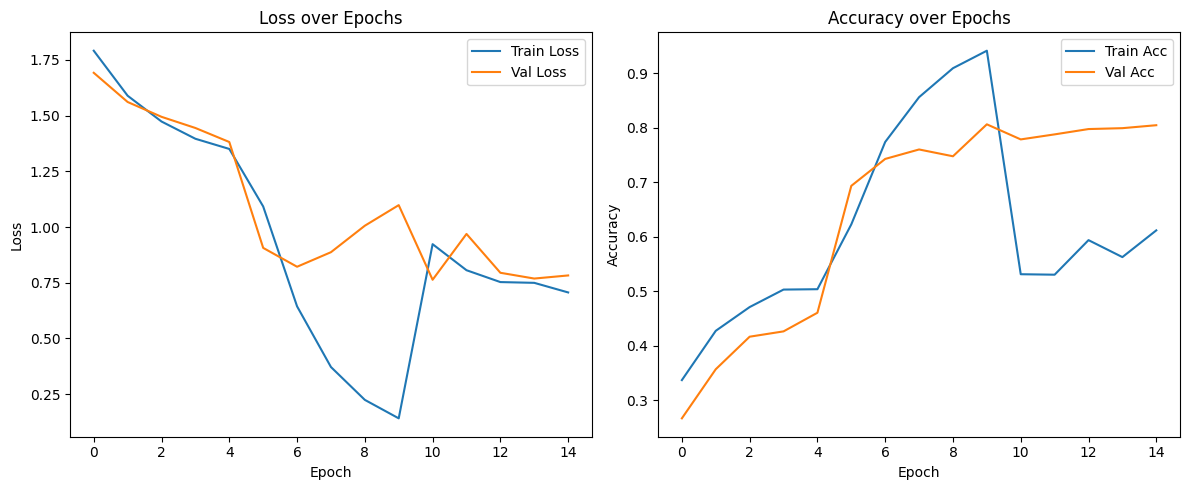

In [6]:
# === 8. Plotting Training and Validation Metrics ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Test Accuracy: 0.8149
Test Loss: 32.2993


<Figure size 800x600 with 0 Axes>

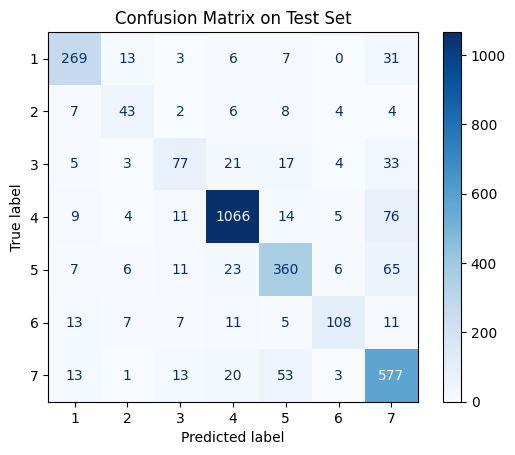

In [7]:
# === Final Evaluation ===
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# === Reload Best Model
model.load_state_dict(torch.load("models/best_effectionet_rafdb.pth"))
model.eval()

# === Inference on Test Set
all_preds, all_labels = [], []
correct, total, test_loss = 0, 0, 0.0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        test_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(f"\nTest Accuracy: {correct / total:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# === Dynamic Class Names from Folder Names ===
# Assuming test images are in folders like: test/0_angry, test/1_disgust, etc.
import re
class_folders = sorted(os.listdir("raf_db_dataset/train"))
class_names = [folder for folder in class_folders if os.path.isdir(os.path.join("raf_db_dataset/train", folder))]

# === Confusion Matrix ===
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix on Test Set")
plt.show()
